# Task 1 — Landsat Image Acquisition and True Color Display

**Study Area:** Rhine Gorge (Mittelrheintal), Germany  
**AOI Centre:** Loreley Rock — 50.1340°N, 7.7290°E  
**WRS Path/Row:** 196 / 025  
**Target Area:** 50 km² (7.07 × 7.07 km)

---

### Why the Rhine Gorge?

The Rhine Gorge (UNESCO World Heritage Site, 2002) is one of the most spectrally
diverse 50 km² windows available in Central Europe. Within a single Landsat scene
you capture:

- **Water body** (Rhine River) — NDVI ≈ −0.8, strong SWIR absorption
- **Terraced vineyards** — unique phenological signature, NDVI ≈ +0.4 to +0.6 in summer
- **Broadleaf & mixed forest** — high NDVI ≈ +0.7 to +0.85
- **Exposed rock / cliff faces** — very low NIR reflectance, distinct SWIR
- **Urban / transport corridors** — impervious surface signature

This class diversity makes it an ideal training ground for CNN-based LULC classification
and connects to a real-world problem: **monitoring climate-driven shifts in vineyard
phenology and extent**, which is an active research area in European remote sensing.

----

### Workflow
1. Authenticate with the USGS EarthExplorer M2M API
2. Search for cloud-free Landsat 8/9 scenes (summer, <20% cloud)
3. Download the best available scene
4. Clip to the 50 km² AOI using rasterio
5. Apply reflectance scaling (Landsat Collection 2 Level-2)
6. Display and save the True Color (RGB) composite
7. Persist band paths for downstream notebooks (NDVI, LULC, CNN)

## Step 1 — Install required libraries

`rasterio` handles all geospatial raster operations (reprojection, windowed reads).  
Run this cell once; comment it out after the first successful install.

In [30]:
!pip install requests numpy matplotlib rasterio

## Step 2 — Import libraries

In [31]:
import os
import json
import tarfile
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.crs import CRS
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [32]:
# Universal path-safety block - ensures we can find the project root and config regardless of where this script is run from.

import os, json

def find_project_root(start=None):
    current = start or os.path.abspath('.')
    for _ in range(8):
        if os.path.isdir(os.path.join(current, 'data', 'landsat')):
            return current
        current = os.path.dirname(current)
    raise FileNotFoundError('Could not find project root — is data/landsat/ present?')

PROJECT_ROOT = find_project_root()
CONFIG_PATH  = os.path.join(PROJECT_ROOT, 'data', 'landsat', 'band_paths.json')

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH) as f:
        cfg = json.load(f)

    SCENE_ID  = cfg.get('scene_id', '')
    SCENE_DIR = os.path.join(PROJECT_ROOT, 'data', 'landsat', SCENE_ID)

    BAND_SUFFIXES = {
        'band2_blue' : '_SR_B2.TIF',
        'band3_green': '_SR_B3.TIF',
        'band4_red'  : '_SR_B4.TIF',
        'band5_nir'  : '_SR_B5.TIF',
        'band6_swir1': '_SR_B6.TIF',
        'band7_swir2': '_SR_B7.TIF',
    }

    if os.path.isdir(SCENE_DIR):
        scene_files = os.listdir(SCENE_DIR)
        for key, suffix in BAND_SUFFIXES.items():
            if not os.path.exists(cfg.get(key, '')):  # only fix if broken
                for fname in scene_files:
                    if fname.upper().endswith(suffix.upper()):
                        cfg[key] = os.path.join(SCENE_DIR, fname)
                        break

    if 'esri_lulc' in cfg:
        LULC_DIR = os.path.join(PROJECT_ROOT, 'data', 'esri_lulc')
        for key, fname in {
            'clipped_path'      : 'esri_lulc_rhine_gorge_clipped.tif',
            'reprojected_path'  : 'esri_lulc_rhine_gorge_utm32n.tif',
            'clipped_to_landsat': 'esri_lulc_clipped_to_landsat.tif',
        }.items():
            full = os.path.join(LULC_DIR, fname)
            if not os.path.exists(cfg['esri_lulc'].get(key, '')):
                cfg['esri_lulc'][key] = full

    if 'ndvi' in cfg:
        ndvi_path = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'ndvi_rhine_gorge.tif')
        if not os.path.exists(cfg['ndvi'].get('tif_path', '')):
            cfg['ndvi']['tif_path'] = ndvi_path

    with open(CONFIG_PATH, 'w') as f:
        json.dump(cfg, f, indent=2)

    print(f'✓  Project root : {PROJECT_ROOT}')
    print(f'✓  Config       : {CONFIG_PATH}')

else:
    print(f'✓  Project root : {PROJECT_ROOT}')
    print('   Config not yet created — will be written by Notebook 01.')

✓  Project root : c:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY
✓  Config       : c:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat\band_paths.json


## Step 3 — Credentials and folder setup

We use the **USGS Machine-to-Machine (M2M) API** — the same backend that powers
EarthExplorer, but accessible programmatically via REST/JSON.


In [33]:

USGS_USERNAME = 'Bhavagna_Mallipeddi'
USGS_TOKEN    = 'FSTcLqt3u3M8P6DPXJ4yHDWrtsgnp9RLH5yBYxxOpf4xeFtSY3MxdV4dKZGpLm_7'

# USGS M2M API base URL (stable endpoint)
API_URL = 'https://m2m.cr.usgs.gov/api/api/json/stable/'

# Output folders
# All raw bands land in data/landsat/, processed outputs in data/outputs/
os.makedirs('../data/landsat',   exist_ok=True)
os.makedirs('../data/outputs',   exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Folder structure ready.')
print('  ../data/landsat/   ← raw .TIF bands will be stored here')
print('  ../data/processed/ ← clipped GeoTIFFs')
print('  ../data/outputs/   ← final maps, NDVI rasters')

Folder structure ready.
  ../data/landsat/   ← raw .TIF bands will be stored here
  ../data/processed/ ← clipped GeoTIFFs
  ../data/outputs/   ← final maps, NDVI rasters


## Step 4 — Authenticate with USGS M2M API

The login endpoint returns a short-lived API key (valid ~2 hours).  
All subsequent requests carry this key in the `X-Auth-Token` header.

In [34]:
login_response = requests.post(
    API_URL + 'login-token',
    json={'username': USGS_USERNAME, 'token': USGS_TOKEN}
)
login_data = login_response.json()

if login_data['errorCode'] is None:
    api_key = login_data['data']
    print('Login successful!')
    print(f'API key (first 10 chars): {api_key[:10]}...')
else:
    raise RuntimeError(f'Login failed: {login_data["errorMessage"]}')

# Attach the key to every future request
HEADERS = {'X-Auth-Token': api_key}

Login successful!
API key (first 10 chars): eyJjaWQiOj...


## Step 5 — Define the Area of Interest (AOI)

The AOI is centred on **Loreley Rock** — the most geographically iconic and spectrally
representative point in the Rhine Gorge. The 7.07 × 7.07 km bounding box captures:
- The full width of the Rhine Valley floor (~400 m wide at this point)
- Steep valley sides with vineyard terraces on both banks
- Mixed broadleaf forest on the plateau edges
- The town of St. Goarshausen and the Loreley bypass road

**WRS-2 Path 196, Row 025** — this is the Landsat ground track that covers the
central Rhine Valley. Scenes are acquired every 16 days.

In [35]:
# AOI definition
# Loreley Rock: the geographic and academic anchor of this study area
CENTRE_LAT = 50.1340   # degrees North
CENTRE_LON =  7.7290   # degrees East

# 50 km² requires a 7.071 × 7.071 km box
# Degree offsets depend on latitude:
#   1° latitude  = 111.0 km  (constant)
#   1° longitude = 111.0 × cos(lat) km  (shrinks toward the poles)
HALF_LAT = (7.071 / 2) / 111.0
HALF_LON = (7.071 / 2) / (111.0 * np.cos(np.radians(CENTRE_LAT)))

AOI_MIN_LAT = CENTRE_LAT - HALF_LAT
AOI_MAX_LAT = CENTRE_LAT + HALF_LAT
AOI_MIN_LON = CENTRE_LON - HALF_LON
AOI_MAX_LON = CENTRE_LON + HALF_LON

# Verify the area comes out to ~50 km²
lat_km   = (AOI_MAX_LAT - AOI_MIN_LAT) * 111.0
lon_km   = (AOI_MAX_LON - AOI_MIN_LON) * 111.0 * np.cos(np.radians(CENTRE_LAT))
AREA_KM2 = lat_km * lon_km

#Search parameters
WRS_PATH = 196
WRS_ROW  = 25

# Summer-only windows: June–August avoids valley fog (common in spring/autumn)
# and snow on the plateau (winter). Rhine valley fog is most frequent Oct–Mar.
SUMMER_WINDOWS = [
    ('2024-06-01', '2024-08-31'),
    ('2023-06-01', '2023-08-31'),
    ('2022-06-01', '2022-08-31'),
    ('2021-06-01', '2021-08-31'),
    ('2020-06-01', '2020-08-31'),
]

MAX_CLOUD = 20  # percent — strict threshold for a clean True Color composite

#Print a summary of the AOI and search parameters for verification
print('═' * 56)
print('  STUDY AREA: Rhine Gorge (Mittelrheintal), Germany')
print('═' * 56)
print(f'  AOI centre   : {CENTRE_LAT}°N,  {CENTRE_LON}°E  (Loreley Rock)')
print(f'  Bounding box : {AOI_MIN_LAT:.5f}°N to {AOI_MAX_LAT:.5f}°N')
print(f'                 {AOI_MIN_LON:.5f}°E to {AOI_MAX_LON:.5f}°E')
print(f'  AOI size     : {lon_km:.2f} km × {lat_km:.2f} km = {AREA_KM2:.2f} km²')
print(f'  WRS Path/Row : {WRS_PATH} / {WRS_ROW:03d}')
print(f'  Cloud limit  : <{MAX_CLOUD}%')
print(f'  Search years : {len(SUMMER_WINDOWS)}  (Jun–Aug only)')
print('═' * 56)

════════════════════════════════════════════════════════
  STUDY AREA: Rhine Gorge (Mittelrheintal), Germany
════════════════════════════════════════════════════════
  AOI centre   : 50.134°N,  7.729°E  (Loreley Rock)
  Bounding box : 50.10215°N to 50.16585°N
                 7.67931°E to 7.77869°E
  AOI size     : 7.07 km × 7.07 km = 50.00 km²
  WRS Path/Row : 196 / 025
  Cloud limit  : <20%
  Search years : 5  (Jun–Aug only)
════════════════════════════════════════════════════════


## Step 6a — Discover USGS metadata filter IDs

The USGS M2M API does not accept plain "path" and "row" strings directly in the
scene-search payload. Instead, it uses internal numeric filter IDs that correspond
to metadata fields. We query those IDs dynamically so the code works even if USGS
updates their field registry.

In [36]:
# Fetch all metadata filters for the Landsat OLI/TIRS Collection 2 Level-2 dataset
response = requests.post(
    API_URL + 'dataset-filters',
    json={'datasetName': 'landsat_ot_c2_l2'},
    headers=HEADERS
)
filters = response.json().get('data', [])

path_filter_id = None
row_filter_id  = None

# Print WRS-related filters so we can verify the IDs
print(f'{"Field Name":<45} {"Filter ID"}')
print('─' * 70)
for f in filters:
    name = f.get('fieldLabel', '')
    fid  = f.get('id', '')
    if any(kw in name.lower() for kw in ['wrs', 'path', 'row', 'cloud']):
        print(f'{name:<45} {fid}')
    # Capture the IDs we need
    if 'path' in name.lower() and 'wrs' in name.lower():
        path_filter_id = fid
    if 'row' in name.lower() and 'wrs' in name.lower():
        row_filter_id = fid

print()
print(f'WRS Path filter ID : {path_filter_id}')
print(f'WRS Row  filter ID : {row_filter_id}')

if not path_filter_id or not row_filter_id:
    raise RuntimeError('Could not find filter IDs. Check the table above for WRS-related fields.')

Field Name                                    Filter ID
──────────────────────────────────────────────────────────────────────
WRS Path                                      5e83d14fb9436d88
WRS Row                                       5e83d14ff1eda1b8

WRS Path filter ID : 5e83d14fb9436d88
WRS Row  filter ID : 5e83d14ff1eda1b8


## Step 6b — Search for Landsat scenes over the Rhine Gorge

We combine three filters: acquisition date window, cloud cover ≤ 20%, and exact
WRS Path/Row. The 'and' filterType requires all three conditions to be satisfied.

In [37]:
print(f'Searching Landsat Collection 2 L2 — Path {WRS_PATH}, Row {WRS_ROW:03d}...')
print(f'Date windows: Jun–Aug, 2020–2024   |   Max cloud: {MAX_CLOUD}%')
print()

all_scenes = []

for start_date, end_date in SUMMER_WINDOWS:
    search_payload = {
        'datasetName': 'landsat_ot_c2_l2',
        'maxResults' : 50,
        'sceneFilter': {
            # Only summer acquisitions — avoids Rhine valley fog
            'acquisitionFilter': {'start': start_date, 'end': end_date},
            # Strict cloud ceiling for a clean true color composite
            'cloudCoverFilter' : {'max': MAX_CLOUD, 'includeUnknown': False},
            # AND filter: must match BOTH path AND row exactly
            'metadataFilter': {
                'filterType'  : 'and',
                'childFilters': [
                    {'filterType': 'value', 'filterId': path_filter_id,
                     'value': str(WRS_PATH), 'operand': '='},
                    {'filterType': 'value', 'filterId': row_filter_id,
                     'value': str(WRS_ROW),  'operand': '='}
                ]
            }
        }
    }

    resp = requests.post(API_URL + 'scene-search', json=search_payload, headers=HEADERS)
    data = resp.json()

    if data.get('errorCode'):
        print(f'  [{start_date[:4]}] API error: {data["errorMessage"]}')
        continue

    results = data.get('data', {}).get('results', [])
    print(f'  [{start_date} → {end_date}]  {len(results):>2} scenes found')
    all_scenes.extend(results)

# De-duplicate (same scene can appear across overlapping search windows)
seen, unique_scenes = set(), []
for s in all_scenes:
    if s['entityId'] not in seen:
        seen.add(s['entityId'])
        unique_scenes.append(s)

print(f'\nTotal unique scenes found: {len(unique_scenes)}')

Searching Landsat Collection 2 L2 — Path 196, Row 025...
Date windows: Jun–Aug, 2020–2024   |   Max cloud: 20%

  [2024-06-01 → 2024-08-31]   4 scenes found
  [2023-06-01 → 2023-08-31]   3 scenes found
  [2022-06-01 → 2022-08-31]   2 scenes found
  [2021-06-01 → 2021-08-31]   2 scenes found
  [2020-06-01 → 2020-08-31]   0 scenes found

Total unique scenes found: 11


## Step 7 — Filter by cloud cover and rank candidates

The USGS cloud cover value is computed over the **entire WRS tile** (~185 × 185 km),
not just on 50 km² AOI. A scene reported at 15% cloud could still have a clear
window over the Rhine Valley —  verified  visually after download.

In [38]:
good_scenes = []

print(f'{"#":<4} {"Scene ID":<50} {"Date":<14} {"Cloud %":<10} {"Status"}')
print('─' * 86)

for i, scene in enumerate(unique_scenes):
    scene_id  = scene.get('entityId', '')
    cloud     = scene.get('cloudCover', 100)
    acq_date  = scene.get('acquisitionDate', 'unknown')
    passes    = cloud < MAX_CLOUD
    status    = 'PASS ' if passes else 'skip '

    print(f'{i:<4} {scene_id:<50} {str(acq_date):<14} {cloud:<10.1f} {status}')

    if passes:
        good_scenes.append(scene)

# Sort by ascending cloud cover — best scene first
good_scenes.sort(key=lambda s: s['cloudCover'])

print(f'\nScenes passing cloud filter : {len(good_scenes)}')

if len(good_scenes) == 0:
    raise RuntimeError(
        'No scenes passed the cloud filter.\n'
        'Try relaxing MAX_CLOUD to 30 in Step 5, or extend the date range.'
    )

print(f'Best candidate             : {good_scenes[0]["entityId"]}')
print(
    f'Date: {good_scenes[0].get("acquisitionDate", good_scenes[0].get("temporalCoverage", {}).get("startDate", "unknown"))[:10]}'
    f'   Cloud: {good_scenes[0]["cloudCover"]:.1f}%'
)

#    Scene ID                                           Date           Cloud %    Status
──────────────────────────────────────────────────────────────────────────────────────
0    LC81960252024242LGN00                              unknown        2.0        PASS 
1    LC81960252024226LGN00                              unknown        2.0        PASS 
2    LC91960252024202LGN00                              unknown        3.0        PASS 
3    LC81960252024178LGN00                              unknown        4.0        PASS 
4    LC81960252023223LGN00                              unknown        1.0        PASS 
5    LC81960252023175LGN00                              unknown        18.0       PASS 
6    LC91960252023167LGN00                              unknown        20.0       skip 
7    LC81960252022236LGN01                              unknown        11.0       PASS 
8    LC81960252022220LGN00                              unknown        2.0        PASS 
9    LC81960252021233LGN00      

## Step 8 — Download the best scene

We request the **full Level-2 surface reflectance bundle** — this gives us all bands
already atmospherically corrected (USGS LaSRC algorithm), which is the correct
starting point for NDVI and CNN training.

The bundle is ~900 MB. Progress is printed every 100 MB.

In [39]:
def get_download_url(scene_id):
    """
    Query USGS for available download products for a given scene,
    then request a signed download URL for the full bundle.
    Returns the URL string, or None if unavailable.
    """
    opts = requests.post(
        API_URL + 'download-options',
        json={'datasetName': 'landsat_ot_c2_l2', 'entityIds': [scene_id]},
        headers=HEADERS
    ).json().get('data', [])

    bundle = next(
        (o for o in opts if 'Bundle' in o.get('productName', '') and o.get('available')),
        None
    )
    if bundle is None:
        bundle = next((o for o in opts if o.get('available')), None)
    if bundle is None:
        return None

    avail = requests.post(
        API_URL + 'download-request',
        json={
            'downloads': [{'entityId': scene_id, 'productId': bundle['id']}],
            'label'    : 'rhine-gorge-landsat'
        },
        headers=HEADERS
    ).json()['data'].get('availableDownloads', [])
    return avail[0]['url'] if avail else None


# Select best scene 
BEST_SCENE    = good_scenes[0]
BEST_SCENE_ID = BEST_SCENE['entityId']
BEST_DATE     = BEST_SCENE.get('acquisitionDate', 'unknown')
BEST_CLOUD    = BEST_SCENE['cloudCover']

print('Selected scene')
print(f'  ID         : {BEST_SCENE_ID}')
print(f'  Date       : {BEST_DATE}')
print(f'  Cloud cover: {BEST_CLOUD:.1f}%')
print()

TAR_PATH       = f'../data/landsat/{BEST_SCENE_ID}.tar'
EXTRACT_FOLDER = f'../data/landsat/{BEST_SCENE_ID}/'

# Download (skip if already on disk)
if os.path.exists(TAR_PATH):
    size_mb = os.path.getsize(TAR_PATH) / (1024 * 1024)
    print(f'Already downloaded — skipping.')
    print(f'  File : {TAR_PATH}')
    print(f'  Size : {size_mb:.0f} MB')
else:
    download_url = get_download_url(BEST_SCENE_ID)
    if download_url is None:
        raise RuntimeError(
            'No download URL returned.\n'
            'If this repeats, try: BEST_SCENE = good_scenes[1] and re-run.'
        )
    resp       = requests.get(download_url, stream=True)
    total_size = int(resp.headers.get('content-length', 0))
    downloaded = 0
    with open(TAR_PATH, 'wb') as fh:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            fh.write(chunk)
            downloaded += len(chunk)
            if total_size > 0 and downloaded % (100 * 1024 * 1024) < 1024 * 1024:
                pct = downloaded / total_size * 100
                print(f'  {downloaded // (1024*1024):>4} MB  ({pct:.0f}%)')
    print('Download complete.')

#  Extract (skip if already done) 
if os.path.exists(EXTRACT_FOLDER) and len(os.listdir(EXTRACT_FOLDER)) > 0:
    n_files = len(os.listdir(EXTRACT_FOLDER))
    print(f'\nAlready extracted — skipping.')
    print(f'  Folder : {EXTRACT_FOLDER}')
    print(f'  Files  : {n_files} files found')
else:
    print('Extracting .tar bundle...')
    os.makedirs(EXTRACT_FOLDER, exist_ok=True)
    with tarfile.open(TAR_PATH, 'r') as tar:
        tar.extractall(path=EXTRACT_FOLDER, filter='data')
    n_files = len(os.listdir(EXTRACT_FOLDER))
    print(f'Extracted {n_files} files to {EXTRACT_FOLDER}')

Selected scene
  ID         : LC81960252021153LGN00
  Date       : unknown
  Cloud cover: 0.0%

Already downloaded — skipping.
  File : ../data/landsat/LC81960252021153LGN00.tar
  Size : 983 MB

Already extracted — skipping.
  Folder : ../data/landsat/LC81960252021153LGN00/
  Files  : 18 files found


## Step 9 — Locate band files

Landsat Collection 2 Level-2 band naming convention:

| Band | Wavelength   | Use in this project          |
|------|-------------|------------------------------|
| B2   | 0.45–0.51 µm (Blue)  | True color display          |
| B3   | 0.53–0.59 µm (Green) | True color display          |
| B4   | 0.64–0.67 µm (Red)   | True color + NDVI numerator |
| B5   | 0.85–0.88 µm (NIR)   | NDVI numerator + CNN feature|
| B6   | 1.57–1.65 µm (SWIR1) | CNN feature (vegetation/soil discrimination) |
| B7   | 2.11–2.29 µm (SWIR2) | CNN feature (rock/bare soil)|

 loaded B2–B5 now; B6 and B7 will be added in Task 4 (CNN).

In [40]:
band2_path = band3_path = band4_path = band5_path = None
band6_path = band7_path = None

print('Scanning extracted files...')
print()

for filename in sorted(os.listdir(EXTRACT_FOLDER)):
    fp = os.path.join(EXTRACT_FOLDER, filename)
    if '_SR_B2.TIF' in filename: band2_path = fp; print(f'  Band 2 (Blue)  : {filename}')
    if '_SR_B3.TIF' in filename: band3_path = fp; print(f'  Band 3 (Green) : {filename}')
    if '_SR_B4.TIF' in filename: band4_path = fp; print(f'  Band 4 (Red)   : {filename}')
    if '_SR_B5.TIF' in filename: band5_path = fp; print(f'  Band 5 (NIR)   : {filename}')
    if '_SR_B6.TIF' in filename: band6_path = fp; print(f'  Band 6 (SWIR1) : {filename}')
    if '_SR_B7.TIF' in filename: band7_path = fp; print(f'  Band 7 (SWIR2) : {filename}')

# Minimum required for Task 1 + Task 3 (NDVI)
if not all([band2_path, band3_path, band4_path, band5_path]):
    raise RuntimeError('One or more required bands (B2–B5) are missing. Check the extracted folder.')

print()
print('All required bands located.')
if band6_path and band7_path:
    print('SWIR bands (B6, B7) also found — will be used in Task 4 (CNN).')

Scanning extracted files...

  Band 2 (Blue)  : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B2.TIF
  Band 3 (Green) : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B3.TIF
  Band 4 (Red)   : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B4.TIF
  Band 5 (NIR)   : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B5.TIF
  Band 6 (SWIR1) : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B6.TIF
  Band 7 (SWIR2) : LC08_L2SP_196025_20210602_20210608_02_T1_SR_B7.TIF

All required bands located.
SWIR bands (B6, B7) also found — will be used in Task 4 (CNN).


## Step 10 — Load and clip bands to the 50 km² AOI

### Landsat Collection 2 Level-2 reflectance scaling

Raw DN (digital number) values in the .TIF files are **not** reflectance. USGS applies
a linear scaling to pack float reflectance into 16-bit integers:

$$\rho = DN \times 0.0000275 - 0.2$$

Valid DN range is **7,273 – 65,455** (corresponding to reflectance 0.0 – 1.6).
Pixels outside this range are fill values (NoData) and must be masked.

In [41]:
def load_band_clipped(filepath, min_lon, min_lat, max_lon, max_lat):
    """
    Read a single Landsat band, clip it to the WGS-84 bounding box,
    apply the Collection 2 L2 reflectance scale, and mask fill pixels.

    Parameters
    ----------
    filepath : str
        Path to a Landsat _SR_B*.TIF file.
    min_lon, min_lat, max_lon, max_lat : float
        WGS-84 bounding box of the AOI.

    Returns
    -------
    numpy.ndarray (float32)
        Clipped reflectance array. Fill pixels are NaN.
    """
    with rasterio.open(filepath) as src:
        # Landsat files are in UTM — reproject the WGS-84 bbox to match
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs,
            min_lon, min_lat, max_lon, max_lat
        )
        # Read only the pixels inside the window — efficient, no full-tile load
        window = from_bounds(left, bottom, right, top, src.transform)
        raw    = src.read(1, window=window).astype(np.float32)

    # Mask fill / saturated values using the official C2 L2 valid DN range
    fill_mask   = (raw < 7273) | (raw > 65455)
    reflectance = raw * 0.0000275 - 0.2          # C2 L2 scale + offset
    reflectance = np.clip(reflectance, 0.0, 1.0)  # physical reflectance ∈ [0, 1]
    reflectance[fill_mask] = np.nan

    return reflectance


print('Loading and clipping bands to Rhine Gorge AOI...')
red_band   = load_band_clipped(band4_path, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
green_band = load_band_clipped(band3_path, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
blue_band  = load_band_clipped(band2_path, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
nir_band   = load_band_clipped(band5_path, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)

# Count valid (non-fill) pixels — should be >90% for a usable scene
valid_pct = 100.0 * np.sum(~np.isnan(red_band)) / red_band.size

print(f'\nClipped image size      : {red_band.shape[1]} × {red_band.shape[0]} pixels')
print(f'Pixel resolution        : 30 m (Landsat OLI)')
print(f'Valid (non-fill) pixels : {valid_pct:.1f}%')
print()
print(f'{"Band":<10} {"Min":>8} {"Max":>8} {"Mean":>8}')
print('─' * 38)
for name, band in [("Red (B4)", red_band), ("Green (B3)", green_band),
                   ("Blue (B2)", blue_band), ("NIR  (B5)", nir_band)]:
    print(f'{name:<10}  {np.nanmin(band):>8.4f} {np.nanmax(band):>8.4f} {np.nanmean(band):>8.4f}')

print()
print('Expected mean reflectance for a clear summer scene: 0.03 – 0.15')

if valid_pct < 50.0:
    print()
    print(f'WARNING: Only {valid_pct:.1f}% valid pixels — the scene swath may not')
    print('cover the AOI centre. Try the next candidate:')
    print('  BEST_SCENE = good_scenes[1]  and re-run from Step 8.')

Loading and clipping bands to Rhine Gorge AOI...

Clipped image size      : 241 × 240 pixels
Pixel resolution        : 30 m (Landsat OLI)
Valid (non-fill) pixels : 100.0%

Band            Min      Max     Mean
──────────────────────────────────────
Red (B4)      0.0073   0.7032   0.0385
Green (B3)    0.0173   0.6279   0.0540
Blue (B2)     0.0006   0.7920   0.0244
NIR  (B5)     0.0003   0.9701   0.3453

Expected mean reflectance for a clear summer scene: 0.03 – 0.15


## Step 11 — Build the RGB composite with percentile stretch

Raw reflectance values in a typical scene cluster in a narrow range (0.02–0.30).
A **2–98 percentile stretch** expands this to the full 0–1 display range, suppressing
outliers (sun glint on the Rhine, shadows in narrow valley folds) while preserving
perceptual detail in both bright and dark land cover classes.

In [42]:
def percentile_stretch(band, low=2, high=98):
    """
    Linearly stretch a band to [0, 1] using percentile clipping.

    This is the standard display enhancement for multispectral imagery.
    NaN pixels (fill values) pass through unchanged.
    """
    valid = band[~np.isnan(band)]
    if valid.size == 0:
        return band
    p_low  = np.percentile(valid, low)
    p_high = np.percentile(valid, high)
    if p_high == p_low:          # flat band — return zeros
        return np.zeros_like(band)
    stretched = (band - p_low) / (p_high - p_low)
    return np.clip(stretched, 0.0, 1.0)


r = percentile_stretch(red_band)
g = percentile_stretch(green_band)
b = percentile_stretch(blue_band)

# Stack into H × W × 3 — replace NaN with 0 (black) for display only
rgb_image = np.dstack([
    np.nan_to_num(r, nan=0.0),
    np.nan_to_num(g, nan=0.0),
    np.nan_to_num(b, nan=0.0)
]).astype(np.float32)

print(f'RGB image shape : {rgb_image.shape}  (rows × cols × channels)')
print(f'Value range     : {rgb_image.min():.3f} – {rgb_image.max():.3f}')
print('Ready to display.')

RGB image shape : (240, 241, 3)  (rows × cols × channels)
Value range     : 0.000 – 1.000
Ready to display.


## Step 12 — Display and save the True Color Composite

The True Color composite (R=B4, G=B3, B=B2) provides the most intuitive visual
reference for the study area. In the Rhine Gorge one should clearly see:
- The **silver-blue thread** of the Rhine River
- **Dark green** forested plateau and valley slopes
- **Yellow-green to beige** vineyard terraces on the sun-facing (south-southwest) slopes
- **Grey-white** cliff exposures and the narrow riparian road/rail corridors

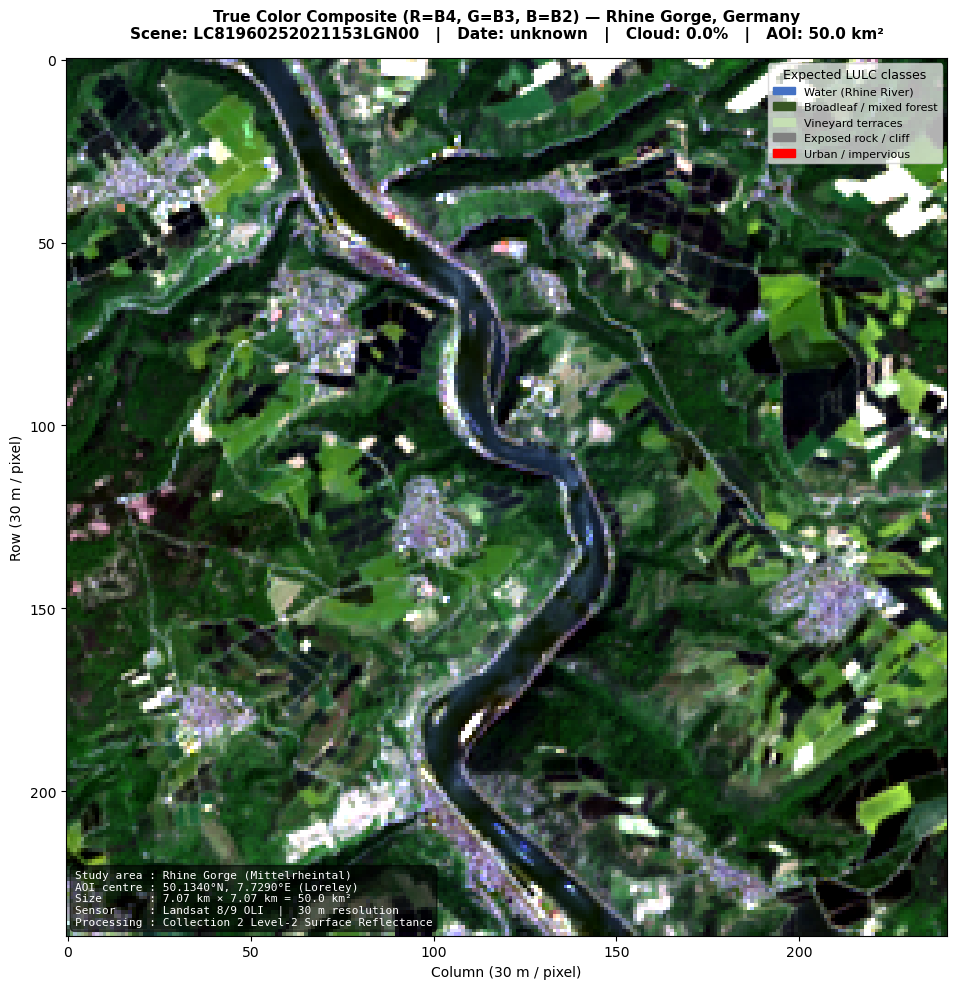

Saved → ../data/outputs/true_color_rhine_gorge.png


In [43]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(rgb_image)

ax.set_title(
    f'True Color Composite (R=B4, G=B3, B=B2) — Rhine Gorge, Germany\n'
    f'Scene: {BEST_SCENE_ID}   |   Date: {BEST_DATE}   |   '
    f'Cloud: {BEST_CLOUD:.1f}%   |   AOI: {AREA_KM2:.1f} km²',
    fontsize=11, fontweight='bold', pad=14
)
ax.set_xlabel('Column (30 m / pixel)', fontsize=10)
ax.set_ylabel('Row (30 m / pixel)', fontsize=10)

#AOI info box (bottom-left)
info_text = (
    f'Study area : Rhine Gorge (Mittelrheintal)\n'
    f'AOI centre : {CENTRE_LAT:.4f}°N, {CENTRE_LON:.4f}°E (Loreley)\n'
    f'Size       : {lon_km:.2f} km × {lat_km:.2f} km = {AREA_KM2:.1f} km²\n'
    f'Sensor     : Landsat 8/9 OLI  |  30 m resolution\n'
    f'Processing : Collection 2 Level-2 Surface Reflectance'
)
ax.text(
    0.01, 0.01, info_text,
    transform=ax.transAxes,
    fontsize=8, color='white', family='monospace',
    va='bottom', ha='left',
    bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.4')
)

#LULC class legend (top-right) — preview of what the CNN will classify
legend_items = [
    mpatches.Patch(color='#4472C4', label='Water (Rhine River)'),
    mpatches.Patch(color='#375623', label='Broadleaf / mixed forest'),
    mpatches.Patch(color='#C6E0B4', label='Vineyard terraces'),
    mpatches.Patch(color='#808080', label='Exposed rock / cliff'),
    mpatches.Patch(color='#FF0000', label='Urban / impervious'),
]
ax.legend(
    handles=legend_items,
    title='Expected LULC classes',
    loc='upper right',
    fontsize=8, title_fontsize=9,
    framealpha=0.7
)

plt.tight_layout()

output_path = '../data/outputs/true_color_rhine_gorge.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {output_path}')

## Step 13 — Persist scene metadata for downstream notebooks

All subsequent notebooks (Task 2: ESRI LULC, Task 3: NDVI, Task 4: CNN) need
the band file paths and AOI coordinates. Saving them to a JSON config file so that
we never hard-code paths in later notebooks — just load `band_paths.json`.

In [ ]:
band_paths = {
    #  Scene metadata
    'scene_id'    : BEST_SCENE_ID,
    'scene_date'  : str(BEST_DATE),
    'cloud_cover' : BEST_CLOUD,
    'sensor'      : 'Landsat 8/9 OLI — Collection 2 Level-2 Surface Reflectance',
    'wrs_path'    : WRS_PATH,
    'wrs_row'     : WRS_ROW,

    #  Band file paths 
    'band2_blue'  : band2_path,
    'band3_green' : band3_path,
    'band4_red'   : band4_path,
    'band5_nir'   : band5_path,
    'band6_swir1' : band6_path,   # None if not extracted — added in Task 4
    'band7_swir2' : band7_path,

    # AOI geometry 
    'aoi': {
        'name'      : 'Rhine Gorge (Mittelrheintal) — Loreley AOI',
        'centre_lat': CENTRE_LAT,
        'centre_lon': CENTRE_LON,
        'min_lat'   : AOI_MIN_LAT,
        'max_lat'   : AOI_MAX_LAT,
        'min_lon'   : AOI_MIN_LON,
        'max_lon'   : AOI_MAX_LON,
        'area_km2'  : round(AREA_KM2, 2)
    }
}

config_path = '../data/landsat/band_paths.json'
with open(config_path, 'w') as fh:
    json.dump(band_paths, fh, indent=2)

print(f'Config saved → {config_path}')
print()
print('Contents:')
print(json.dumps(band_paths, indent=2))

Config saved → ../data/landsat/band_paths.json

Contents:
{
  "scene_id": "LC81960252021153LGN00",
  "scene_date": "unknown",
  "cloud_cover": 0,
  "sensor": "Landsat 8/9 OLI \u2014 Collection 2 Level-2 Surface Reflectance",
  "wrs_path": 196,
  "wrs_row": 25,
  "band2_blue": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B2.TIF",
  "band3_green": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B3.TIF",
  "band4_red": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B4.TIF",
  "band5_nir": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B5.TIF",
  "band6_swir1": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B6.TIF",
  "band7_swir2": "../data/landsat/LC81960252021153LGN00/LC08_L2SP_196025_20210602_20210608_02_T1_SR_B7.TIF",
  "aoi": {
    "name": "Rhine Gorge (Mittelrheintal) \u2014 Loreley AOI",
    "centre_lat"

In [45]:
import os, json

LANDSAT_DIR = r'C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat'
SCENE_DIR   = os.path.join(LANDSAT_DIR, 'LC81960252021153LGN00')
DATA_DIR    = os.path.dirname(LANDSAT_DIR)

# Read existing json
config_path = os.path.join(LANDSAT_DIR, 'band_paths.json')
with open(config_path) as f:
    band_paths = json.load(f)

# Overwrite all band paths with correct absolute paths
band_paths['band2_blue']  = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B2.TIF')
band_paths['band3_green'] = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B3.TIF')
band_paths['band4_red']   = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B4.TIF')
band_paths['band5_nir']   = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B5.TIF')
band_paths['band6_swir1'] = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B6.TIF')
band_paths['band7_swir2'] = os.path.join(SCENE_DIR, 'LC08_L2SP_196025_20210602_20210608_02_T1_SR_B7.TIF')

# Save it back
with open(config_path, 'w') as f:
    json.dump(band_paths, f, indent=2)

print("band_paths.json updated! Verifying...")
for key in ['band2_blue','band3_green','band4_red','band5_nir','band6_swir1','band7_swir2']:
    path = band_paths[key]
    print(f"  {key}: {'OK' if os.path.exists(path) else 'MISSING'}")

band_paths.json updated! Verifying...
  band2_blue: OK
  band3_green: OK
  band4_red: OK
  band5_nir: OK
  band6_swir1: OK
  band7_swir2: OK


# Extracting TAR file for further usage

In [2]:
import os, tarfile, json

landsat_dir = r'C:\Users\SIRIUS\OneDrive\Desktop\TEB_GERMANY\data\landsat'
scene_id    = 'LC81960252021153LGN00'
scene_dir   = os.path.join(landsat_dir, scene_id)
tar_path    = os.path.join(landsat_dir, f'{scene_id}.tar')

# Extract all TIF files
with tarfile.open(tar_path) as tf:
    for member in tf.getmembers():
        if member.name.endswith('.TIF'):
            tf.extract(member, scene_dir)
            print(f'Extracted: {member.name}')

# Fix the JSON paths
config_path = os.path.join(landsat_dir, 'band_paths.json')
with open(config_path) as f:
    cfg = json.load(f)

for key, suffix in {
    'band2_blue' : '_SR_B2.TIF',
    'band3_green': '_SR_B3.TIF',
    'band4_red'  : '_SR_B4.TIF',
    'band5_nir'  : '_SR_B5.TIF',
}.items():
    for fname in os.listdir(scene_dir):
        if fname.endswith(suffix):
            cfg[key] = os.path.join(scene_dir, fname)
            print(f'Updated {key}: {cfg[key]}')
            break

with open(config_path, 'w') as f:
    json.dump(cfg, f, indent=2)
print('\nband_paths.json updated.')

C:\Users\SIRIUS\AppData\Local\Temp\ipykernel_24292\3372639376.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(member, scene_dir)


Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_QA_PIXEL.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_QA_RADSAT.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B1.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B2.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B3.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B4.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B5.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B6.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_B7.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_SR_QA_AEROSOL.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_ST_ATRAN.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_ST_B10.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_ST_CDIST.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_ST_DRAD.TIF
Extracted: LC08_L2SP_196025_20210602_20210608_02_T1_ST_EMIS.TIF
Extracted: LC08_L2SP_196025_20210602_2021060